# TensorFlow overview
While the homeworks will be written in torch, the labs are written in tensorflow. Most of the time, only a very basic tensorflow knowledge suffices for solving them. Since tensorflow is not used during other ML courses at MIMUW, we will introduce it briefly here.

In [1]:
import tensorflow as tf
import numpy as np
import keras

2025-04-26 17:54:42.650333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745682882.671687   11522 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745682882.679362   11522 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745682882.696743   11522 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745682882.696759   11522 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745682882.696760   11522 computation_placer.cc:177] computation placer alr

#Tensors

Example tensor operations in tensorflow




In [2]:
print(tf.math.add(1, 2))
print(tf.math.add([1, 2], [3, 4]))
print(tf.math.square(5))
print(tf.math.reduce_sum([1, 2, 3]))

# Operator overloading is also supported
print(tf.math.square(2) + tf.math.square(3))

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor([4 6], shape=(2,), dtype=int32)
tf.Tensor(25, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(13, shape=(), dtype=int32)


2025-04-26 17:54:48.565361: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In contrast to pytorch, in tensorflow numpy arrays can be used instead of tf.Tensor - they get converted automatically:

In [3]:
import numpy as np

ndarray = np.ones([3, 3])

print("TensorFlow operations convert numpy arrays to Tensors automatically")
tensor = tf.math.multiply(ndarray, 42)
print(tensor)

print("And NumPy operations convert Tensors to NumPy arrays automatically")
print(np.add(tensor, 1))

TensorFlow operations convert numpy arrays to Tensors automatically
tf.Tensor(
[[42. 42. 42.]
 [42. 42. 42.]
 [42. 42. 42.]], shape=(3, 3), dtype=float64)
And NumPy operations convert Tensors to NumPy arrays automatically
[[43. 43. 43.]
 [43. 43. 43.]
 [43. 43. 43.]]


Tensorflow automatically decides which device to choose for execution - it moves tensors between GPU and CPU as needed. Of course it is also possible to do it manually.

In [4]:
x = tf.random.uniform([3, 3])

print("Is there a GPU available: "),
print(tf.config.list_physical_devices("GPU"))

print("Is the Tensor on GPU #0:  "),
print(x.device.endswith('GPU:0'))


Is there a GPU available: 
[]
Is the Tensor on GPU #0:  
False


In [5]:
###########################################
# Implement mse loss                      #
# using vector operations from tensorflow #
###########################################

def mse_loss(y_true, y_pred):
  ### TODO ###
  square_error = tf.math.square(tf.math.subtract(y_true, y_pred))
  result = tf.math.reduce_mean(square_error)

  return result
  ### END ###


loss_fn = tf.keras.losses.MeanSquaredError()
y_true = np.random.rand(4, 10)
y_pred = np.random.rand(4, 10)
print(loss_fn(y_true, y_pred))
print(mse_loss(y_true, y_pred.astype(np.float64)))



tf.Tensor(0.1477961, shape=(), dtype=float32)
tf.Tensor(0.14779608859133142, shape=(), dtype=float64)


## Dataset Definition
The dataset we will be using for network training is Cifar10.

In [6]:
dataset = tf.keras.datasets.cifar10

(x_train, y_train), (x_test, y_test) = dataset.load_data()

##############################################
# Scale the data to be in (0, 1) interval    #
##############################################
### TODO ###

def normalize(tensor):
  max_, min_ = tf.math.reduce_max(tensor), tf.math.reduce_min(tensor)
  return tf.math.divide(tensor - min_, max_ - min_)

def check_norm(t):
  print(tf.math.reduce_min(t), tf.math.reduce_max(t))

x_train = normalize(x_train)
x_test = normalize(x_test)

check_norm(x_train)
check_norm(x_test)

### END ###

2025-04-26 17:54:53.859961: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.
2025-04-26 17:54:53.941371: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

## Keras Sequential
The most straightforward wat to define a model is using Keras Sequential.

In [8]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

Epoch 1/5


/home/nojak/Git/ML12/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1683 - loss: 2.1837
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2086 - loss: 2.0605
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2143 - loss: 2.0303
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2290 - loss: 2.0056
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2379 - loss: 1.9887
313/313 - 1s - 2ms/step - accuracy: 0.2695 - loss: 1.9364


We can use `keras.utils.plot_model` to plot the model.

/home/nojak/Git/ML12/venv


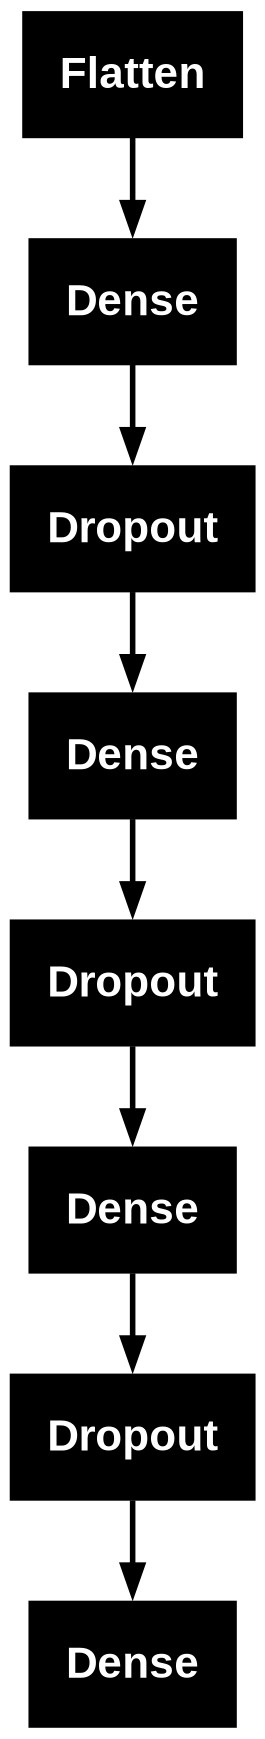

In [9]:
!echo $VIRTUAL_ENV
keras.utils.plot_model(model, "dense_model.png")

We can call the model as in torch. The mode that the model is called in can be specified by passing the `training` argument.

In [14]:
features = tf.random.normal((10, 32, 32, 3))
predictions = model(features, training=False)

print(predictions)

tf.Tensor(
[[-2.58813024e-01 -1.75281286e-01 -1.13414310e-01 -7.88784176e-02
  -1.03491724e-01 -2.04895422e-01 -4.35483396e-01 -3.17141265e-02
  -4.59432632e-01 -4.51537251e-01]
 [ 4.47100252e-01  2.31236786e-01 -2.76415616e-01 -3.04739356e-01
  -7.30777025e-01 -3.49345922e-01 -1.28794217e+00 -1.10855728e-01
   9.05511260e-01  4.20502961e-01]
 [-1.42526150e-01  1.88373998e-02 -2.45609760e-01 -1.20857358e-03
  -2.86320686e-01 -9.75605100e-02 -3.33400011e-01 -4.80142534e-02
  -1.44519866e-01 -2.04751268e-02]
 [ 3.86321306e-01  6.25219405e-01 -6.67259634e-01 -7.36541152e-01
  -8.98303330e-01 -9.90532756e-01 -1.76029098e+00 -6.13475978e-01
   6.65001392e-01  8.50239575e-01]
 [-8.22201818e-02 -1.76831335e-01 -1.67564914e-01 -4.22292799e-02
  -3.17326218e-01 -3.87367606e-03 -2.21857309e-01  4.79781255e-02
   1.83342248e-02 -1.42764002e-01]
 [-4.35619392e-02  3.03867042e-01 -4.15690809e-01 -2.17583388e-01
  -5.35836577e-01 -4.16481435e-01 -6.68552279e-01 -3.17401886e-02
   9.18603092e-02  4.5

Then we can convert it to logits and find the predictions

In [ ]:
##########################################
#   Convert the predictions to logits    #
#   And calculate the resulting label    #
##########################################

### TODO ###
probs = tf.math.softmax(predictions, axis = 1)

logits = tf.math.log(probs)

samples = tf.random.categorical(logits, num_samples=1)

### END ###

tf.Tensor(
[[4]
 [8]
 [7]
 [0]
 [2]
 [9]
 [8]
 [8]
 [8]
 [2]], shape=(10, 1), dtype=int64)


Using your background from the dnn course and layers from `tf.keras.layers`  define the model so that the accuracy of 0.5 is reached within 5 epochs.

In [42]:
##############################################
# Define a convolutional network             #
# That gets an accuracy over 50% in 5 epochs #
##############################################

### TODO ###

### END ###

model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters = 32, kernel_size = 3),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 32, kernel_size = 3),
  tf.keras.layers.ReLU(),
  tf.keras.layers.MaxPool2D(strides = 2),

  tf.keras.layers.Conv2D(filters = 64, kernel_size = 3),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 64, kernel_size = 3),
  tf.keras.layers.ReLU(),
  tf.keras.layers.MaxPool2D(strides = 2),

  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same'),
  tf.keras.layers.ReLU(),
  tf.keras.layers.MaxPool2D(strides = 2),

  tf.keras.layers.Flatten(input_shape=(2, 2, 128)),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# print(model(x_train[:2]))
# print(x_train.shape)

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

Epoch 1/5
 436/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 52ms/step - accuracy: 0.1410 - loss: 2.2010

KeyboardInterrupt: 

## Keras Functional API
Keras functional API allows for creating more flexible models than `keras.Sequential`. It will therefore be useful during this course.

In [ ]:
import keras
from keras import layers

Let's build the same dense model as before.

In [ ]:
inputs = keras.Input(shape=(3072,))
dense = layers.Dense(64, activation="relu")
x = dense(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10)(x)

model = keras.Model(inputs=inputs, outputs=outputs)

And again fit it to the data.

In [ ]:
##################################
# Flatten the images             #
##################################
### TODO ###

### DONE ###

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

##############################################
# Train the model with batch size 128        #
# And learning rate 0.001                    #
##############################################
### TODO ###

### DONE ###

test_loss, test_acc = model.evaluate(x_flat_test,  y_test, verbose=2)

Define the same network as in the previous exercise, but using the functional approach.

Write a training loop that does the same thing as happens above manually.

Create network with a plot like this on right.

In [ ]:
######################################
# Define the same convnet as before, #
# But use the functional API         #
######################################

### TODO ###

### END ###

model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

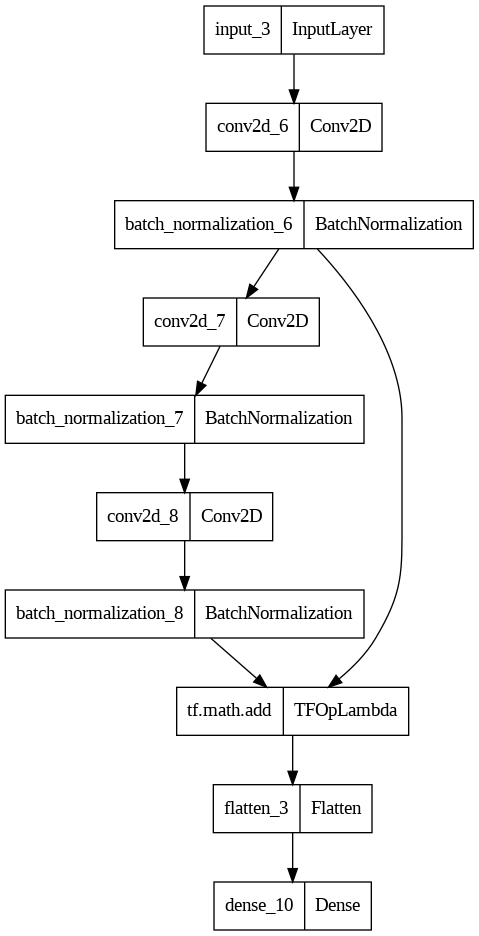

In [ ]:
######################################
# Add a residual connection to your #
# convnet, use the functional API   #
######################################

### TODO ###

### END ###

model = keras.Model(inputs=inputs, outputs=outputs)

keras.utils.plot_model(model, "residual_model.png")

Sometimes just using `.fit` method might not be enough. It is also possible to write the training loop more from scratch.

In [ ]:
batch_size = 32

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
ds_train_batch = train_dataset.batch(batch_size)
ds_test_batch = test_dataset.batch(batch_size)

def simple_forward(x, model, training):
  ########################################
  #   Get the predictions from the model #
  ########################################

  ### TODO ###

  ### END ###

def loss(model, x, y, training, forward_fn):
  # training=training is needed only if there are layers with different
  # behavior during training versus inference (e.g. Dropout).
  y_ = forward_fn(x, model, training)
  return loss_fn(y_true=y, y_pred=y_)

@tf.function
def grad(model, inputs, targets, forward_fn):
  with tf.GradientTape() as tape:
    loss_value = loss(model, inputs, targets, training=True, forward_fn=forward_fn)

  return loss_value, tape.gradient(loss_value, model.trainable_variables)

def run_training(optimizer, num_epoch, model, forward_fn):

  for epoch in range(num_epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()

    test_epoch_loss_avg = tf.keras.metrics.Mean()
    test_epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()

    for x, y in ds_train_batch:
      loss_value, grads = grad(model, x, y, forward_fn)

      ########################
      # Apply the gradients  #
      ########################

      ### TODO ###

      ### END ###

      epoch_loss_avg.update_state(loss_value)
      epoch_accuracy.update_state(y, model(x, training=True))

    print("Epoch {:03d}: Loss: {:.3f}, Accuracy: {:.3%}".format(epoch,
                                                                epoch_loss_avg.result(),
                                                                  epoch_accuracy.result()))

    ######################
    # Run the test epoch #
    ######################
    ### TODO ###

    ### END ###

optimizer = tf.keras.optimizers.Adam()
num_epochs = 5

run_training(optimizer, num_epochs, model, simple_forward)


Humans have two eyes. Let's try to simulate something similar with a neural network, that is train a separate encoder for the left and right parts of the image and then encode them together. Your network should have a plot similar to this one: 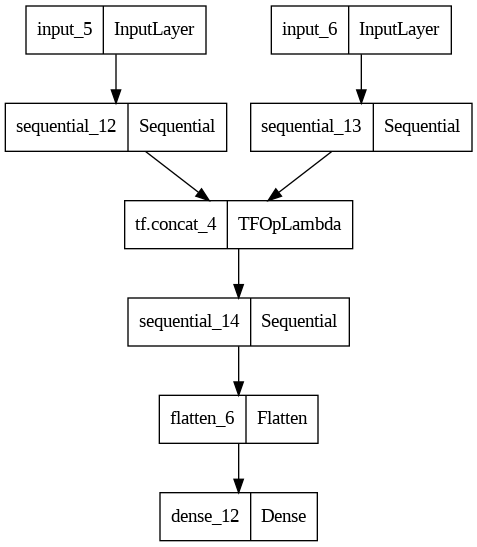

In [ ]:
#######################################
# Split x_train and x_test into       #
# two inputs with shapes (32, 16, 3)  #
#######################################

### TODO ###

### END ###

In [ ]:
num_epochs = 5

def get_block(input_shape):
  model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(3, 3, activation='relu', input_shape=input_shape, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(3, 3, activation='relu', input_shape=input_shape, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(3, 3, activation='relu', input_shape=input_shape, padding='same'),
    tf.keras.layers.BatchNormalization(),
  ])

  return model



def build_model(left_model, right_model, out_model):
  #######################################
  # Build the model so that its plot    #
  # resembles the one from the image    #
  #######################################

  ### TODO ###

  ### END ###


In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

left_model = get_block((32, 16, 3))
right_model = get_block((32, 16, 3))
out_model = get_block((32, 32, 3))

model = build_model(left_model, right_model, out_model)
keras.utils.plot_model(model, "two_inputs_model.png")

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

###################
# Fit the model   #
###################
### TODO ###

### END ###

#######################
# Evaluate the model  #
#######################
### TODO ###

### END ###